# Notebook to study the Synaptic LIF model in `Lava`

This model corresponds to a 2nd order LIF model, similar to the Current-Base Leaky-Integrate-and-Fire.

The Cuba LIF model has 2 exponentially-decaying terms and is defined reccurently as:

$$
I_{syn}(t+1) = (1-d_u) I_{syn}(t) + a_{in} \\

V(t+1) = (1-d_v) U(t) + I_{syn}(t+1) + bias \\
 
S_{out}(t+1) = V(t+1) \ge V_{thr} \\

If \ S_{out}(t+1) = 1 \rightarrow V(t+1) = 0
$$

Thus, here the membrane potential is instantenously set to 0 when a spike is generated. Equivalent to setting `reset_delay` to False in `snn-torch` Synaptic model

In [172]:
from lava.proc.lif.process import LIF
from lava.proc.dense.process import Dense

LIF?

Init signature: LIF(*args, **kwargs)
Docstring:     
Leaky-Integrate-and-Fire (LIF) neural Process.

LIF dynamics abstracts to:
u[t] = u[t-1] * (1-du) + a_in         # neuron current
v[t] = v[t-1] * (1-dv) + u[t] + bias  # neuron voltage
s_out = v[t] > vth                    # spike if threshold is exceeded
v[t] = 0                              # reset at spike

Parameters
----------
shape : tuple(int)
    Number and topology of LIF neurons.
u : float, list, numpy.ndarray, optional
    Initial value of the neurons' current.
v : float, list, numpy.ndarray, optional
    Initial value of the neurons' voltage (membrane potential).
du : float, optional
    Inverse of decay time-constant for current decay. Currently, only a
    single decay can be set for the entire population of neurons.
dv : float, optional
    Inverse of decay time-constant for voltage decay. Currently, only a
    single decay can be set for the entire population of neurons.
bias_mant : float, list, numpy.ndarray, optiona

In [173]:
# Define the number of neurons in each LIF Layer
n1 = 1   # Let's create a simple program with only 1 LIF layer

## Define the parameters from the `snn-torch` model

In [174]:
import numpy as np

snn_params = {
    "alpha": 0.9,
    "beta": 0.8,
    "v_thr": 1,
    "weights": 0.2, # input weight
    "num_steps": 12, # number of time steps to run the simulation
    "input_period": 5,    # Input is feeding a spike every 5 time steps
}

## Convert the Parameters to work with Lava

In [175]:
# Convert the snn.synaptic parameters to Lava's LIF parameters
v_init = 0
du = 1 - snn_params["alpha"]
dv = 1 - snn_params["beta"]
v_thr = snn_params["v_thr"]
weights_scale = snn_params["weights"]
num_steps = snn_params["num_steps"] + snn_params["input_period"] + 1    # Adding more steps because the Spiker Input feeds the first spike at time step period+1

use_refractory = False
refrac_period = 10

# Simulation Parameters
virtual_time_step_interval = 1  

In [176]:
# Create Processes
lif1 = LIF(
    shape=(n1,),  # There is 1 neuron (same as the snn-torch example)
    vth=v_thr,  # TODO: Verify these initial values
    v=v_init,
    dv=dv,    # Inverse of decay time-constant for voltage decay
    du=du,  # Inverse of decay time-constant for current decay
    bias_mant=0,
    bias_exp=0,
    name="lif1"
)

## Prepare the input data

In [177]:
import torch
# Periodic spiking input, spk_in = 0.2 V
spk_period = torch.cat((torch.ones(1)*weights_scale, torch.zeros(4)), 0)
spk_in = spk_period.repeat(3)

# Print the input spikes
print(f"Input spikes shape: {spk_in.shape}:")
print(spk_in[:num_steps])

Input spikes shape: torch.Size([15]):
tensor([0.2000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.2000, 0.0000, 0.0000, 0.0000, 0.0000])


## Create the Lava Process that feeds the spikes

In [178]:
from lava.proc.lif.process import LIF, LIFRefractory
from lava.proc.spiker.process import Spiker

# Create Processes
input_layer = Spiker(
    shape=(n1,),
    name="input_layer",
    payload=1,
    period=5    # First spike is emmitted at time step period + 1
)

# Define Dense Layer to Connect Input Process and the Cuba LIF
# Define the matrix of weights
dense_weights = np.eye(n1)
dense_weights = dense_weights * weights_scale
dense_input = Dense(weights=dense_weights, name="DenseInput")     # 1-1 connectivity with the Middle Layer (should be a 2x2 matrix right now)

## Connect the Layers


In [179]:
# Connect the input layer to the Dense Layer
input_layer.s_out.connect(dense_input.s_in)

# Connect the Dense Layer to the LIF Layer
dense_input.a_out.connect(lif1.a_in)

### Take a look at the connections between Processes

In [180]:
for proc in [input_layer, dense_input, lif1]:
    for port in proc.in_ports:
        print(f"Proc: {proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
    for port in proc.out_ports:
        print(f"Proc: {proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")

Proc: input_layer Port Name: s_out Size: 1
Proc: DenseInput Port Name: s_in  Size: 1
Proc: DenseInput Port Name: a_out Size: 1
Proc: lif1  Port Name: a_in  Size: 1
Proc: lif1  Port Name: s_out Size: 1


### Record Internal Vars over time
To record the evolution of the internal variables over time, we need a `Monitor`. For this example, we want to record the membrane potential of the `LIF` Layer, hence we need 1 `Monitors`.

We can define the `Var` that a `Monitor` should record, as well as the recording duration, using the `probe` function

In [181]:
from lava.proc.monitor.process import Monitor

monitor_lif1_v = Monitor()
monitor_lif1_u = Monitor()

# Connect the monitors to the variables we want to monitor
monitor_lif1_v.probe(lif1.v, num_steps)
monitor_lif1_u.probe(lif1.u, num_steps)

## Execution
Now that we have defined the network, we can execute it. We will use the `run` function to execute the network.

### Run Configuration and Conditions

In [182]:
from lava.magma.core.run_conditions import RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg

# run_condition = RunContinuous()   # TODO: Change to this one
run_condition = RunSteps(num_steps=num_steps)
run_cfg = Loihi1SimCfg(select_tag="floating_pt")

In [183]:
print(f"Running for {num_steps} steps")

Running for 18 steps


### Execute

In [184]:
lif1.run(condition=run_condition, run_cfg=run_cfg)

### Retrieve recorded data

In [185]:
data_lif1_v = monitor_lif1_v.get_data()
data_lif1_u = monitor_lif1_u.get_data()

data_lif1 = data_lif1_v.copy()
data_lif1["lif1"]["u"] = data_lif1_u["lif1"]["u"]   # Merge the dictionaries to contain both voltage and current

In [186]:
# Check the shape to verify if it is printing the voltage for every step
len(data_lif1['lif1']['v'])     # Indeed, there are 300 values (same as the number of steps we ran the simulation for)

18

### Ignore the first `period + 1` time steps since there is not input being fed to the network

In [187]:
# Ignore the first period+1 time steps
data_lif1['lif1']['v'] = data_lif1['lif1']['v'][snn_params["input_period"]+1:]
data_lif1['lif1']['u'] = data_lif1['lif1']['u'][snn_params["input_period"]+1:]

In [188]:
print("New number of recorded steps:", len(data_lif1['lif1']['v']))

New number of recorded steps: 12


In [189]:
data_lif1

{'lif1': {'v': array([[0.2       ],
         [0.34      ],
         [0.434     ],
         [0.493     ],
         [0.52562   ],
         [0.738594  ],
         [0.8771634 ],
         [0.9593901 ],
         [0.99940552],
         [0.        ],
         [0.38783369],
         [0.65931727]]),
  'u': array([[0.2       ],
         [0.18      ],
         [0.162     ],
         [0.1458    ],
         [0.13122   ],
         [0.318098  ],
         [0.2862882 ],
         [0.25765938],
         [0.23189344],
         [0.2087041 ],
         [0.38783369],
         [0.34905032]])}}

### Plot the recorded data

In [190]:
from snntorch import spikeplot as splt
import matplotlib.pyplot as plt

#@title Plotting Settings

"""
Plot the input spikes, synaptic current, membrane potential and output spikes
"""
def plot_spk_cur_mem_spk(spk_in, syn_rec, mem_rec, spk_rec, title):
  # Generate Plots
  fig, ax = plt.subplots(4, figsize=(8,7), sharex=True, 
                        gridspec_kw = {'height_ratios': [0.4, 1, 1, 0.4]})

  # Plot input current
  splt.raster(spk_in, ax[0], s=400, c="black", marker="|")
  ax[0].set_ylabel("Input Spikes")
  ax[0].set_title("Synaptic Conductance-based Neuron Model With Input Spikes")
  ax[0].set_yticks([]) 

  # Plot membrane potential
  ax[1].plot(syn_rec)
  ax[1].set_ylim([0, 0.5])
  ax[1].set_ylabel("Synaptic Current ($I_{syn}$)")
  plt.xlabel("Time step")

  # Plot membrane potential
  ax[2].plot(mem_rec)
  ax[2].set_ylim([0, 1.5])
  ax[2].set_ylabel("Membrane Potential ($U_{mem}$)")
  ax[2].axhline(y=1, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  plt.xlabel("Time step")

  # Plot output spike using spikeplot
  splt.raster(spk_rec, ax[3], s=400, c="black", marker="|")
  plt.ylabel("Output spikes")
  ax[3].set_yticks([]) 

  plt.show()

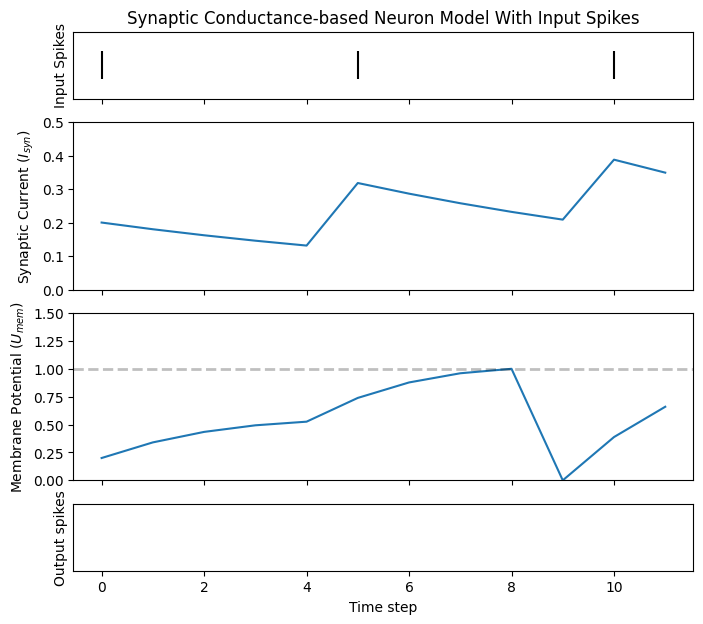

In [191]:
plot_spk_cur_mem_spk(spk_in[:snn_params["num_steps"]],
                     data_lif1['lif1']['u'],
                     data_lif1['lif1']['v'], 
                     torch.zeros(0),   # For now, don't show the spikes since I did not fetch the data
                     "Lava LIF Neuron Model With Input Spikes")